# Quantium Virtual Internship - Retail Strategy and Analytics
## Task 1: Customer Analytics and Insights

# Step 1: Data Loading and Initial Exploration

In [49]:
# Import libraries for data analysis and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# Load transaction and customer datasets
transaction_data = pd.read_excel("QVI_transaction_data.xlsx")
customer_data = pd.read_csv("QVI_purchase_behaviour.csv")

In [51]:
# Preview datasets
display(transaction_data.head())
display(customer_data.head())

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [52]:
# Check column names and data types for transaction data
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [53]:
# Check column names and data types for customer data
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


# Step 2: Data Cleaning

In [54]:
# Check missing values
print("Transaction missing values:")
print(transaction_data.isnull().sum())

print("\nCustomer missing values:")
print(customer_data.isnull().sum())

Transaction missing values:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

Customer missing values:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [55]:
# Convert DATE to datetime
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], origin ='1899-12-30', unit='D')
transaction_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [56]:
# Check for duplicates
duplicates = transaction_data.duplicated().sum()
print(duplicates)

duplicate_rows = transaction_data[transaction_data.duplicated(keep=False)]
print(duplicate_rows)

1
             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
124843 2018-10-01        107          107024  108462        45   
124845 2018-10-01        107          107024  108462        45   

                                     PROD_NAME  PROD_QTY  TOT_SALES  
124843  Smiths Thinly Cut   Roast Chicken 175g         2        6.0  
124845  Smiths Thinly Cut   Roast Chicken 175g         2        6.0  


In [57]:
# Remove the duplicates
transaction_data = transaction_data.drop_duplicates()

In [58]:
# Checking for products other than chips
transaction_data['PROD_NAME'].str.lower().str.contains('salsa').sum()

18094

In [59]:
transaction_data[transaction_data['PROD_NAME'].str.lower().str.contains('salsa')]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
25,2019-05-15,39,39144,35506,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
32,2019-05-20,45,45127,41122,64,Red Rock Deli SR Salsa & Mzzrlla 150g,2,5.4
44,2018-08-18,56,56013,50090,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6
63,2019-05-15,82,82480,82047,101,Doritos Salsa Medium 300g,1,2.6
...,...,...,...,...,...,...,...,...
264675,2019-04-20,265,265103,263419,59,Old El Paso Salsa Dip Tomato Med 300g,1,5.1
264678,2019-03-30,265,265111,263428,35,Woolworths Mild Salsa 300g,1,1.5
264719,2018-10-28,266,266278,264104,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6
264734,2019-01-11,267,267324,264374,41,Doritos Salsa Mild 300g,1,2.6


In [60]:
# Remove salsa products
transaction_data = transaction_data[~transaction_data['PROD_NAME'].str.lower().str.contains('salsa')]

In [61]:
# Check summary statistics for quantity and sales
transaction_data[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,246741.000000,246741.000000
mean,1.908061,7.321328
std,0.659832,3.077833
min,1.000000,1.700000
25%,2.000000,5.800000
50%,2.000000,7.400000
75%,2.000000,8.800000
max,200.000000,650.000000


In [62]:
# Look at transactions with unusually high quantities
outliers = transaction_data[transaction_data['PROD_QTY']>10]
print(outliers)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [63]:
# Identify outlier customers with unusually high purchase quantities
outlier_customer = transaction_data.loc[transaction_data['PROD_QTY'] > 10, 'LYLTY_CARD_NBR'].unique()

print("Outlier customer(s):", outlier_customer)

Outlier customer(s): [226000]


In [64]:
# Remove outlier customer(s)
transaction_data = transaction_data[~transaction_data['LYLTY_CARD_NBR'].isin(outlier_customer)]

# Reset index after cleaning
transaction_data.reset_index(drop=True, inplace=True)

print("Transaction data cleaned.")
print("Remaining rows:", len(transaction_data))

Transaction data cleaned.
Remaining rows: 246739


In [65]:
# Validate cleaned transaction data
transaction_data[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,246739.000000,246739.000000
mean,1.906456,7.316118
std,0.342500,2.474901
min,1.000000,1.700000
25%,2.000000,5.800000
50%,2.000000,7.400000
75%,2.000000,8.800000
max,5.000000,29.500000


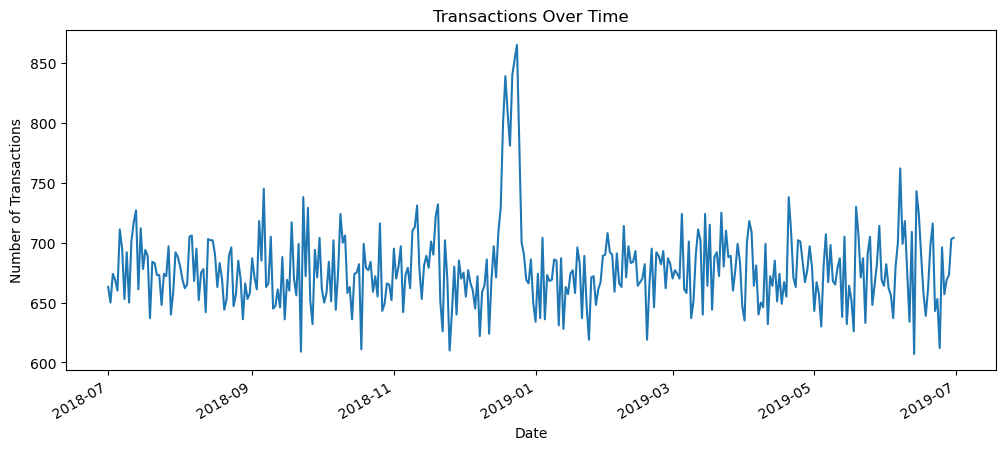

In [66]:
# Check transactions over time
transactions_per_day = transaction_data.groupby('DATE').size()

plt.figure(figsize=(12, 5))
transactions_per_day.plot()
plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.show()

In [67]:
display(transaction_data['DATE'].min())
display(transaction_data['DATE'].max())

Timestamp('2018-07-01 00:00:00')

Timestamp('2019-06-30 00:00:00')

In [68]:
# Check for missing dates between 1 July 2018 and 30 June 2019
all_dates = pd.date_range(start='2018-07-01', end='2019-06-30')

transactions_by_day = transaction_data.groupby('DATE').size().reset_index(name='TRANSACTIONS')

date_check = pd.DataFrame({'DATE': all_dates}).merge(
    transactions_by_day,
    on='DATE',
    how='left'
)

date_check['TRANSACTIONS'] = date_check['TRANSACTIONS'].fillna(0)

# Show dates with zero transactions
date_check[date_check['TRANSACTIONS'] == 0]

,DATE,TRANSACTIONS
177,2018-12-25,0.0


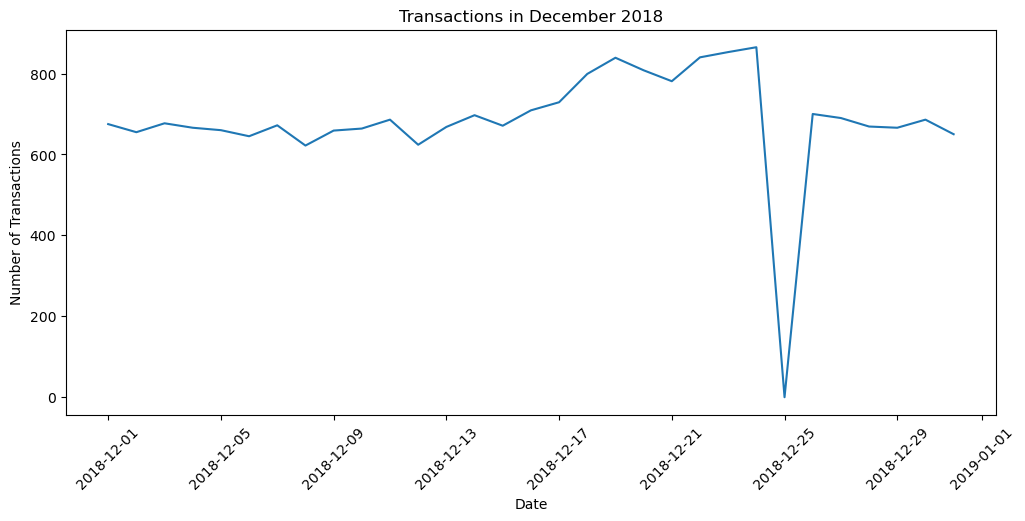

In [69]:
# Zoom into December 2018 transactions
december_data = date_check[
    (date_check['DATE'] >= '2018-12-01') &
    (date_check['DATE'] <= '2018-12-31')
]

plt.figure(figsize=(12, 5))
sns.lineplot(data=december_data, x='DATE', y='TRANSACTIONS')
plt.title("Transactions in December 2018")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

# Step 3: Feature Engineering

In [70]:
# Extract brand: first word in PROD_NAME
transaction_data['BRAND'] = transaction_data['PROD_NAME'].str.split().str[0]

# Extract pack size using regex: find numbers followed by 'g'
transaction_data['PACK_SIZE'] = transaction_data['PROD_NAME'].str.extract(r'(\d+)').astype(float)

# Quick check of new columns
print(transaction_data[['PROD_NAME', 'BRAND', 'PACK_SIZE']].head())


                                  PROD_NAME    BRAND  PACK_SIZE
0    Natural Chip        Compny SeaSalt175g  Natural      175.0
1                  CCs Nacho Cheese    175g      CCs      175.0
2    Smiths Crinkle Cut  Chips Chicken 170g   Smiths      170.0
3    Smiths Chip Thinly  S/Cream&Onion 175g   Smiths      175.0
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g   Kettle      150.0


In [71]:
# Standardise inconsistent brand names
transaction_data['BRAND'] = transaction_data['BRAND'].replace({
    'RED': 'RRD',
    'Dorito': 'Doritos',
    'Smith': 'Smiths'
})

In [72]:
# Check distribution of pack sizes
transaction_data['PACK_SIZE'].describe()

count    246739.000000
mean        175.583523
std          59.432239
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

In [73]:
# Count occurrences of each pack size (sorted)
transaction_data['PACK_SIZE'].value_counts().sort_index()

PACK_SIZE
70.0      1507
90.0      3008
110.0    22387
125.0     1454
134.0    25102
135.0     3257
150.0    40203
160.0     2970
165.0    15297
170.0    19983
175.0    66389
180.0     1468
190.0     2995
200.0     4473
210.0     6272
220.0     1564
250.0     3169
270.0     6285
330.0    12540
380.0     6416
Name: count, dtype: int64

# Step 4:  Merge Customer Data with Transactions

In [74]:
# Merge transaction data with customer data
data = pd.merge(transaction_data, customer_data, on='LYLTY_CARD_NBR', how='left')

# Check result
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND,PACK_SIZE,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural,175.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs,175.0,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths,170.0,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,Smiths,175.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,Kettle,150.0,MIDAGE SINGLES/COUPLES,Budget


In [75]:
# Check if any customer data is missing after merge
data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
BRAND               0
PACK_SIZE           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [76]:
# Create unit price to analyse average price paid per pack
data['UNIT_PRICE'] = data['TOT_SALES'] / data['PROD_QTY']

In [77]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND,PACK_SIZE,LIFESTAGE,PREMIUM_CUSTOMER,UNIT_PRICE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural,175.0,YOUNG SINGLES/COUPLES,Premium,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs,175.0,MIDAGE SINGLES/COUPLES,Budget,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths,170.0,MIDAGE SINGLES/COUPLES,Budget,1.45
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,Smiths,175.0,MIDAGE SINGLES/COUPLES,Budget,3.00
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,Kettle,150.0,MIDAGE SINGLES/COUPLES,Budget,4.60


# Step 5: Customer Segmentation Analysis

In [78]:
# Total sales by customer segment
sales_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index(name='TOTAL_SALES')
# total_spend_segment = total_spend_segment.sort_values(by='TOT_SALES', ascending=False)

sales_segment

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_SALES
0,MIDAGE SINGLES/COUPLES,Budget,33345.70
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25
2,MIDAGE SINGLES/COUPLES,Premium,54443.85
3,NEW FAMILIES,Budget,20607.45
4,NEW FAMILIES,Mainstream,15979.70
5,NEW FAMILIES,Premium,10760.80
6,OLDER FAMILIES,Budget,156863.75
7,OLDER FAMILIES,Mainstream,96413.55
8,OLDER FAMILIES,Premium,75242.60
9,OLDER SINGLES/COUPLES,Budget,127833.60


In [79]:
# Average sales per transaction by customer segment
avg_spend_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].mean().reset_index(name='AVG_SALES_PER_TRANSACTION')
# avg_spend_segment = avg_spend_segment.sort_values(by='TOT_SALES', ascending=False)

avg_spend_segment

,LIFESTAGE,PREMIUM_CUSTOMER,AVG_SALES_PER_TRANSACTION
0,MIDAGE SINGLES/COUPLES,Budget,7.108442
1,MIDAGE SINGLES/COUPLES,Mainstream,7.637156
2,MIDAGE SINGLES/COUPLES,Premium,7.152371
3,NEW FAMILIES,Budget,7.297256
4,NEW FAMILIES,Mainstream,7.313364
5,NEW FAMILIES,Premium,7.231720
6,OLDER FAMILIES,Budget,7.291241
7,OLDER FAMILIES,Mainstream,7.281440
8,OLDER FAMILIES,Premium,7.232779
9,OLDER SINGLES/COUPLES,Budget,7.444305


In [80]:
# Number of unique customers per segment
customers_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index(name='CUSTOMERS')

customers_segment

,LIFESTAGE,PREMIUM_CUSTOMER,CUSTOMERS
0,MIDAGE SINGLES/COUPLES,Budget,1474
1,MIDAGE SINGLES/COUPLES,Mainstream,3298
2,MIDAGE SINGLES/COUPLES,Premium,2369
3,NEW FAMILIES,Budget,1087
4,NEW FAMILIES,Mainstream,830
5,NEW FAMILIES,Premium,575
6,OLDER FAMILIES,Budget,4611
7,OLDER FAMILIES,Mainstream,2788
8,OLDER FAMILIES,Premium,2231
9,OLDER SINGLES/COUPLES,Budget,4849


In [81]:
# Average units per customer
units_segment = data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
).agg(
    TOTAL_UNITS=('PROD_QTY', 'sum'),
    CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
).reset_index()

units_segment['AVG_UNITS_PER_CUSTOMER'] = units_segment['TOTAL_UNITS'] / units_segment['CUSTOMERS']

units_segment

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_UNITS,CUSTOMERS,AVG_UNITS_PER_CUSTOMER
0,MIDAGE SINGLES/COUPLES,Budget,8883,1474,6.026459
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080
2,MIDAGE SINGLES/COUPLES,Premium,14400,2369,6.078514
3,NEW FAMILIES,Budget,5241,1087,4.821527
4,NEW FAMILIES,Mainstream,4060,830,4.891566
5,NEW FAMILIES,Premium,2769,575,4.815652
6,OLDER FAMILIES,Budget,41853,4611,9.076773
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
8,OLDER FAMILIES,Premium,20239,2231,9.071717
9,OLDER SINGLES/COUPLES,Budget,32883,4849,6.781398


In [82]:
# Average price paid per unit by segment
price_segment = data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['UNIT_PRICE'].mean().reset_index(name='AVG_UNIT_PRICE')

price_segment

,LIFESTAGE,PREMIUM_CUSTOMER,AVG_UNIT_PRICE
0,MIDAGE SINGLES/COUPLES,Budget,3.743328
1,MIDAGE SINGLES/COUPLES,Mainstream,3.994241
2,MIDAGE SINGLES/COUPLES,Premium,3.770698
3,NEW FAMILIES,Budget,3.917688
4,NEW FAMILIES,Mainstream,3.916133
5,NEW FAMILIES,Premium,3.872110
6,OLDER FAMILIES,Budget,3.745340
7,OLDER FAMILIES,Mainstream,3.737077
8,OLDER FAMILIES,Premium,3.717000
9,OLDER SINGLES/COUPLES,Budget,3.882096


In [83]:
# Combine all segment metrics into one table
final_metrics = (
    sales_segment.merge(avg_spend_segment, on=['LIFESTAGE', 'PREMIUM_CUSTOMER'])
                 .merge(customers_segment, on=['LIFESTAGE', 'PREMIUM_CUSTOMER'])
                 .merge(units_segment[['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_UNITS_PER_CUSTOMER']],on=['LIFESTAGE', 'PREMIUM_CUSTOMER'])
                 .merge(price_segment, on=['LIFESTAGE', 'PREMIUM_CUSTOMER']))

final_metrics

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_SALES,AVG_SALES_PER_TRANSACTION,CUSTOMERS,AVG_UNITS_PER_CUSTOMER,AVG_UNIT_PRICE
0,MIDAGE SINGLES/COUPLES,Budget,33345.70,7.108442,1474,6.026459,3.743328
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25,7.637156,3298,6.432080,3.994241
2,MIDAGE SINGLES/COUPLES,Premium,54443.85,7.152371,2369,6.078514,3.770698
3,NEW FAMILIES,Budget,20607.45,7.297256,1087,4.821527,3.917688
4,NEW FAMILIES,Mainstream,15979.70,7.313364,830,4.891566,3.916133
5,NEW FAMILIES,Premium,10760.80,7.231720,575,4.815652,3.872110
6,OLDER FAMILIES,Budget,156863.75,7.291241,4611,9.076773,3.745340
7,OLDER FAMILIES,Mainstream,96413.55,7.281440,2788,9.255380,3.737077
8,OLDER FAMILIES,Premium,75242.60,7.232779,2231,9.071717,3.717000
9,OLDER SINGLES/COUPLES,Budget,127833.60,7.444305,4849,6.781398,3.882096


# Step 6: Insights and Recommendation

In [84]:
# Sort final metrics to identify the highest sales segments
top_sales_segments = final_metrics.sort_values(by='TOTAL_SALES', ascending=False)

top_sales_segments

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_SALES,AVG_SALES_PER_TRANSACTION,CUSTOMERS,AVG_UNITS_PER_CUSTOMER,AVG_UNIT_PRICE
6,OLDER FAMILIES,Budget,156863.75,7.291241,4611,9.076773,3.745340
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20,7.551279,7917,4.575597,4.065642
13,RETIREES,Mainstream,145168.95,7.269352,6358,5.925920,3.844294
15,YOUNG FAMILIES,Budget,129717.95,7.302705,3953,8.722995,3.760737
9,OLDER SINGLES/COUPLES,Budget,127833.60,7.444305,4849,6.781398,3.882096
10,OLDER SINGLES/COUPLES,Mainstream,124648.50,7.306049,4858,6.712021,3.814665
11,OLDER SINGLES/COUPLES,Premium,123531.55,7.460085,4682,6.769116,3.893236
12,RETIREES,Budget,105916.30,7.445786,4385,6.141847,3.924404
7,OLDER FAMILIES,Mainstream,96413.55,7.281440,2788,9.255380,3.737077
14,RETIREES,Premium,91296.65,7.461315,3812,6.103358,3.920942


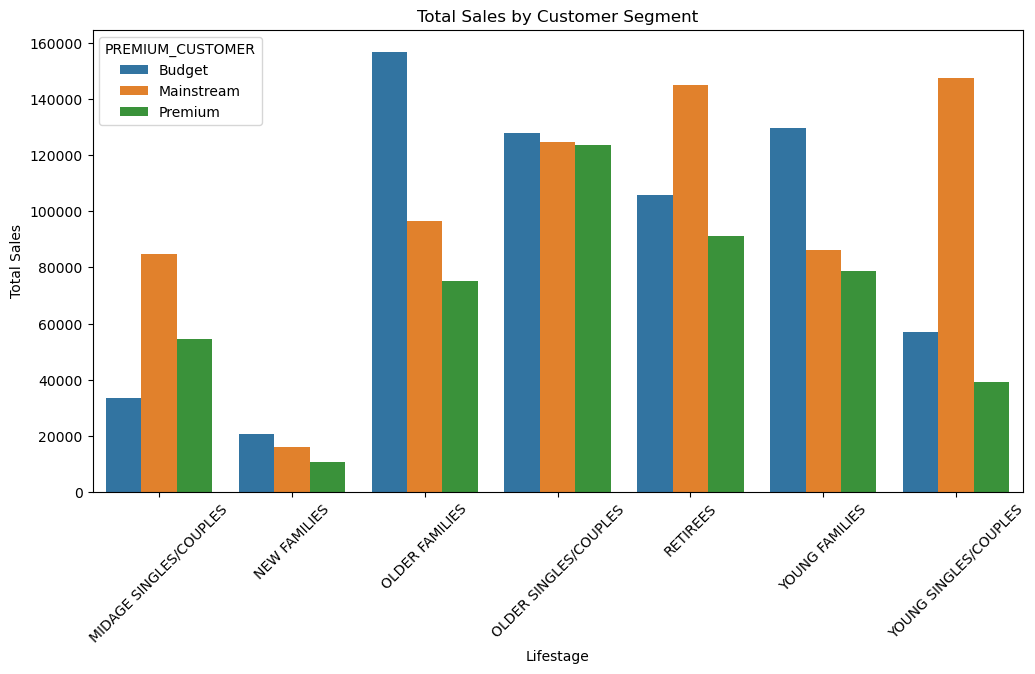

In [85]:
# Visualise total sales by customer segment
plt.figure(figsize=(12, 6))
sns.barplot(
    data=final_metrics,
    x='LIFESTAGE',
    y='TOTAL_SALES',
    hue='PREMIUM_CUSTOMER'
)
plt.title("Total Sales by Customer Segment")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [86]:
# Select the highest-value customer segment based on total sales
top_segment = top_sales_segments.iloc[0]

top_lifestage = top_segment['LIFESTAGE']
top_customer_type = top_segment['PREMIUM_CUSTOMER']

print("Top Segment:")
print("Lifestage:", top_lifestage)
print("Customer Type:", top_customer_type)
print("Total Sales:", round(top_segment['TOTAL_SALES'], 2))

Top Segment:
Lifestage: OLDER FAMILIES
Customer Type: Budget
Total Sales: 156863.75


In [87]:
# Filter data for the highest-value customer segment
target_segment = data[
    (data['LIFESTAGE'] == top_lifestage) &
    (data['PREMIUM_CUSTOMER'] == top_customer_type)
]

target_segment.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND,PACK_SIZE,LIFESTAGE,PREMIUM_CUSTOMER,UNIT_PRICE
29896,2018-07-21,77,2330461,236777,87,Infuzions BBQ Rib Prawn Crackers 110g,1,3.8,Infuzions,110.0,OLDER FAMILIES,Budget,3.8
29897,2019-05-20,1,1367,424,7,Smiths Crinkle Original 330g,1,5.7,Smiths,330.0,OLDER FAMILIES,Budget,5.7
29898,2018-08-17,3,3088,1462,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,Kettle,175.0,OLDER FAMILIES,Budget,5.4
29899,2018-08-14,3,3147,1698,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,Smiths,330.0,OLDER FAMILIES,Budget,5.7
29900,2019-05-16,3,3206,1979,71,Twisties Cheese Burger 250g,1,4.3,Twisties,250.0,OLDER FAMILIES,Budget,4.3


In [88]:
# Compare target segment behaviour with overall customer behaviour
target_comparison = pd.DataFrame({
    'Metric': [
        'Average Sales per Transaction',
        'Average Units per Customer',
        'Average Unit Price'
    ],
    'Target Segment': [
        target_segment['TOT_SALES'].mean(),
        target_segment['PROD_QTY'].mean(),
        target_segment['UNIT_PRICE'].mean()
    ],
    'Overall Customers': [
        data['TOT_SALES'].mean(),
        data['PROD_QTY'].mean(),
        data['UNIT_PRICE'].mean()
    ]
})

target_comparison

,Metric,Target Segment,Overall Customers
0,Average Sales per Transaction,7.291241,7.316118
1,Average Units per Customer,1.945384,1.906456
2,Average Unit Price,3.745340,3.832419


In [89]:
# Identify top brands purchased by the target segment
top_brands = (
    target_segment['BRAND']
    .value_counts()
    .reset_index()
)

top_brands.columns = ['BRAND', 'PURCHASE_COUNT']

top_brands.head(10)

,BRAND,PURCHASE_COUNT
0,Kettle,3320
1,Smiths,2948
2,Doritos,2032
3,Pringles,1996
4,RRD,1218
5,Thins,1171
6,WW,1057
7,Infuzions,908
8,Twisties,810
9,Cobs,760


In [90]:
# Identify top pack sizes purchased by target segment
top_pack_sizes = (
    target_segment['PACK_SIZE']
    .value_counts()
    .reset_index()
)

top_pack_sizes.columns = ['PACK_SIZE', 'PURCHASE_COUNT']

top_pack_sizes.head(10)

,PACK_SIZE,PURCHASE_COUNT
0,175.0,5808
1,150.0,3588
2,134.0,1996
3,110.0,1803
4,170.0,1786
5,165.0,1358
6,330.0,1092
7,270.0,532
8,380.0,510
9,210.0,505


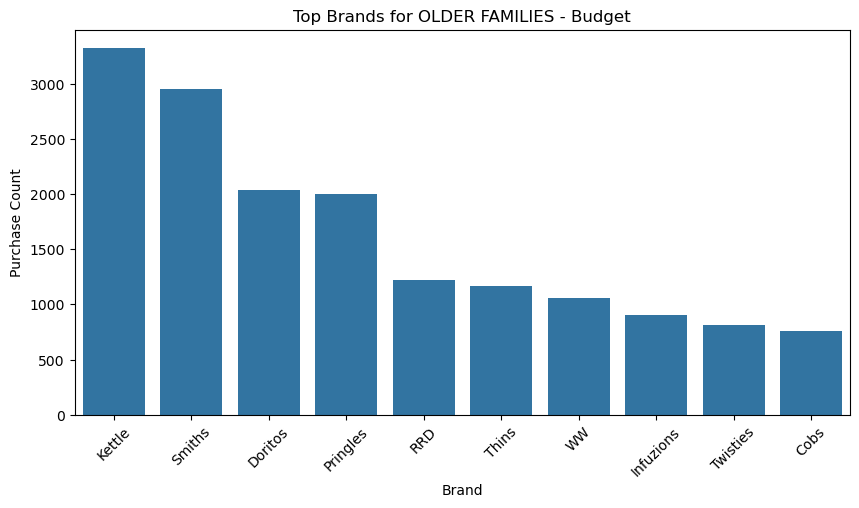

In [91]:
# Visualise top brands for target segment
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_brands.head(10),
    x='BRAND',
    y='PURCHASE_COUNT'
)
plt.title(f"Top Brands for {top_lifestage} - {top_customer_type}")
plt.xlabel("Brand")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.show()

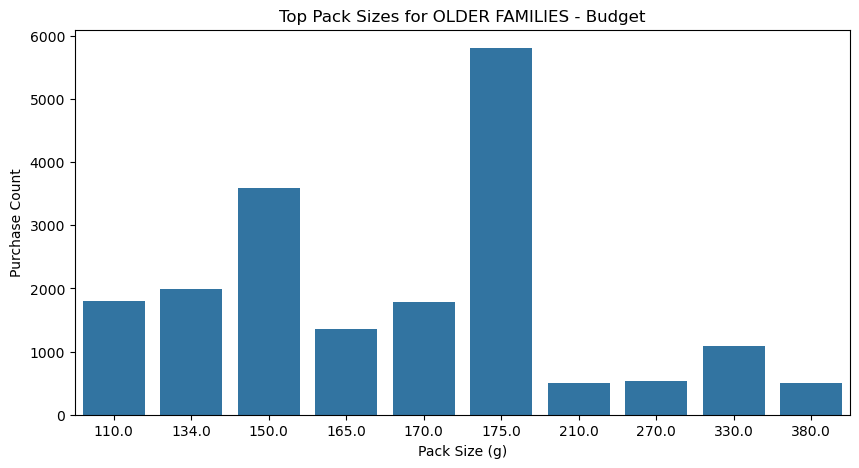

In [92]:
# Visualise top pack sizes for target segment
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_pack_sizes.head(10),
    x='PACK_SIZE',
    y='PURCHASE_COUNT'
)
plt.title(f"Top Pack Sizes for {top_lifestage} - {top_customer_type}")
plt.xlabel("Pack Size (g)")
plt.ylabel("Purchase Count")
plt.show()

## Key Insights and Recommendation

The analysis identified key customer segments and purchasing behaviours within the chips category.

### Key Findings
- Older Families - Budget customers generated the highest total sales.
- Young Singles/Couples - Mainstream customers also contributed strongly to total sales.
- Older and Young Families purchased more units per customer, indicating volume-driven purchasing behaviour.
- Mainstream Young Singles/Couples paid a higher average unit price, suggesting lower price sensitivity and stronger preference for premium-style products.
- A statistical t-test confirmed that the higher unit price paid by Mainstream Young/Midage Singles/Couples was statistically significant.
- The target segment showed strong preference for brands such as Kettle, Smiths, Doritos, and Pringles.
- Medium-sized pack formats such as 175g and 150g were the most commonly purchased pack sizes.

### Recommendation
The Category Manager should prioritise high-value customer segments using targeted promotions and product placement strategies.

- Older Families particularly Budget customers should be targeted using larger pack sizes and multi-buy offers, as they purchase higher chip volumes.
- Mainstream Young Singles/Couples can be targeted using popular premium-style brands and convenient pack sizes, as they show strong sales contribution and willingness to pay higher prices.
- Marketing campaigns should prioritise the most preferred brands (Kettle, Smiths, Doritos, and Pringles) and popular pack sizes (175g and 150g) to maximise category sales.